# **Business Case 1: Segmenting Clients - Asset Management**

This Section is specifically dedicated at finding the clusters that best describe the **"investor" personas**. 




In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import gower
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display, Markdown

In [2]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)

In [3]:
# Drop the column by its actual name (e.g., 'ID' or the actual name of the column)
data = data.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop

# Let's inspect the first 5 record
data.head()

,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data
We extract the variables of interest, also dividing into:
* **Numerical**.
* **Categorical** (excluding the ID, which is not informative at this level).


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

## Outlier Analysis

In [4]:
def find_outliers_selective(df, columns_to_check):
    """
    df: Your pandas DataFrame
    columns_to_check: List of strings (names of continuous numerical columns)
    """
    rows_to_drop = set()
    
    for col in columns_to_check:
        data = df[col].values
        mean, std = data.mean(), data.std()
        
        # 3-sigma rule
        lower, upper = mean - 3*std, mean + 3*std
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        if not outliers.empty:
            print(f"Feature '{col}' has {len(outliers)} outliers.")
            rows_to_drop.update(outliers.index.tolist())
            
    # Drop rows by index
    df_cleaned = df.drop(index=list(rows_to_drop))
    print(f"\nDropped {len(rows_to_drop)} total rows.")
    return df_cleaned

# Usage: Only pass Age or Family Members, NOT Gender/Occupation/Percentiles
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = find_outliers_selective(data, continuous_cols)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


# FAMD

**Factor Analysis of Mixed Data (FAMD)** is a dimensionality reduction technique that simultaneously analyzes datasets containing both numerical (e.g., income) and categorical (e.g., investment type) variables. It mathematically balances these different data types so neither dominates, allowing you to compress complex information into a few key dimensions for accurate clustering and visualization.

Compared to a normal distance the FAMD automatically assigns weights instead of having to choose them ourselves.

 # Why FAMD?
 We selected Factor Analysis of Mixed Data (FAMD) over pairwise 
 distance metrics (like Gower) or custom functions for three reasons:

 1. **Coordinate Generation**: FAMD projects mixed data into continuous 
    Euclidean space. This allows the use of scalable algorithms like 
    K-Means, whereas Gower outputs a distance matrix requiring slower 
    algorithms like K-Medoids.

 2. **Multicollinearity**: Financial variables (Wealth, Income) are correlated. 
    FAMD extracts orthogonal components, preventing the clustering 
    algorithm from "double-counting" these features.

 3. **Objective Scaling**: FAMD mathematically balances the variance of 
    continuous variables with the frequencies of categorical variables 
    (like Investments), avoiding arbitrary, subjective weighting.

In [16]:
# OBJECTIVE 1: FAMD PIPELINE for CROSS-SELLING

# For Cross-Selling we select seven 7 feature: 'Wealth', 'Income', 'Debt', 'Saving','Luxury','LifeStyle', 'Investments'
active_cols = ['Wealth', 'Income', 'Debt', 'Saving','Luxury','LifeStyle','Investments']
df_active_mixed = data[active_cols].copy()

# Ensure 'Investments' is treated as a category so FAMD knows what to do
df_active_mixed['Investments'] = df_active_mixed['Investments'].astype(str)

print("Original Mixed Dataset:")
display(df_active_mixed.head(5))

# Initialize and Fit FAMD
# We reduce the 6 mixed variables down to 5 purely continuous latent dimensions
famd = prince.FAMD(
    n_components=4,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Transform the mixed data into pure continuous coordinates
X_famd = famd.fit_transform(df_active_mixed)
X_famd.columns = ['Dim_1', 'Dim_2', 'Dim_3','Dim_4']

print("\nFAMD Continuous Coordinates (Ready for Clustering):")
display(X_famd.head(3))

# Check the Variance Explained - for see if we captured the actual data
explained_variance = famd.percentage_of_variance_
total_var = sum(explained_variance)

display(Markdown(f"\nTotal Variance Explained by 4 Dimensions: **{total_var:.2f}%**"))

Original Mixed Dataset:


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
0,0.702786,0.668046,0.262070,0.283222,0.897369,0.607877,1
1,0.915043,0.858453,0.730430,0.821590,0.913729,0.862271,3
2,0.898316,0.926818,0.441272,0.503790,0.765199,0.755404,3
3,0.423180,0.538797,0.600401,0.691240,0.517209,0.334432,2
4,0.731404,0.806659,0.831449,0.615916,0.611610,0.908878,2



FAMD Continuous Coordinates (Ready for Clustering):


,Dim_1,Dim_2,Dim_3,Dim_4
0,-0.640950,2.206368,-0.121340,-0.171734
1,-3.923503,-0.139871,-0.123500,-0.232439
2,-2.450747,1.272439,0.267361,0.218499



Total Variance Explained by 4 Dimensions: **72.79%**

# Interpretation of FAMD

Let's understand what the new Continuous Dimensions created by FAMD actually represent. We can do this by identifying which features they are composed of and analyzing their correlations.

1. **Feature Contributions**: Understanding how much each original variable "weighs" in the creation of each new dimension.

2. **Feature Correlations**: The relationship between the new dimensions and the variables that compose them.

In [6]:
# Extract the column contributions to each FAMD dimension
contributions = famd.column_contributions_.style.format("{:.2%}")
print("--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---")
display(contributions)

# Extract column correlations
row_coordinates = famd.transform(df_active_mixed)
numerical_cols = df_active_mixed.select_dtypes(include=['number']).columns

# Calculate correlation between original numerical data and FAMD dimensions
correlations = df_active_mixed[numerical_cols].apply(lambda x: row_coordinates.corrwith(x))

print("\n--- FEATURE CORRELATIONS WITH DIMENSIONS ---")
display(correlations.round(3))

--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---


component,0,1,2,3
variable,,,,
Wealth,17.38%,2.12%,29.83%,30.96%
Income,17.84%,3.33%,2.91%,63.81%
Debt,15.52%,19.86%,21.92%,0.77%
Saving,12.17%,46.43%,7.61%,0.16%
Luxury,19.57%,11.14%,0.07%,0.02%
LifeStyle,16.60%,12.32%,29.16%,4.07%
Investments,1.84%,9.58%,16.99%,0.43%



--- FEATURE CORRELATIONS WITH DIMENSIONS ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle
component,,,,,,
0,-0.728,-0.738,-0.688,-0.609,-0.772,-0.711
1,0.136,0.171,-0.417,-0.637,0.312,0.328
2,0.430,0.134,-0.369,0.217,0.021,-0.425
3,-0.413,0.593,-0.065,0.030,-0.010,-0.150


# Interpretation of FAMD

Analyzing the results for the 4 components, we notice:

* **Component 0 (Dim1)** -> Negative correlation with all variables; high if the overall financial capacity is low.

* **Component 1 (Dim2)** -> Negative correlation with *Saving* and *Debt*; it represents spending behavior and is high when there is a low propensity to save.

* **Component 2 (Dim3)** -> Positive correlation with *Wealth* and negative with *LifeStyle* and *Debt*; high for those who accumulate wealth while maintaining a low-cost lifestyle.

* **Component 3** -> Positive correlation with *Income* and negative with *Wealth*; high for people who earn a lot but are not wealthy.

<br>

# Clustering Evaluation

After performing k-means clustering with different k values, **we need to evaluate the quality of our clustering solutions**.

In order to quantitatively evaluate our clusters, we'll use three widely-recognized clustering validation metrics:

1. **[Calinski-Harabasz Index](https://en.wikipedia.org/wiki/Calinski%E2%80%93Harabasz_index)**
   
2. **[Davies-Bouldin Index](https://en.wikipedia.org/wiki/Davies%E2%80%93Bouldin_index)**

3. **[Silhouette Score](https://en.wikipedia.org/wiki/Silhouette_clustering)**


The code produces three plots showing how each metric varies with the number of clusters (k). This helps **identify the optimal number of clusters** according to different criteria.

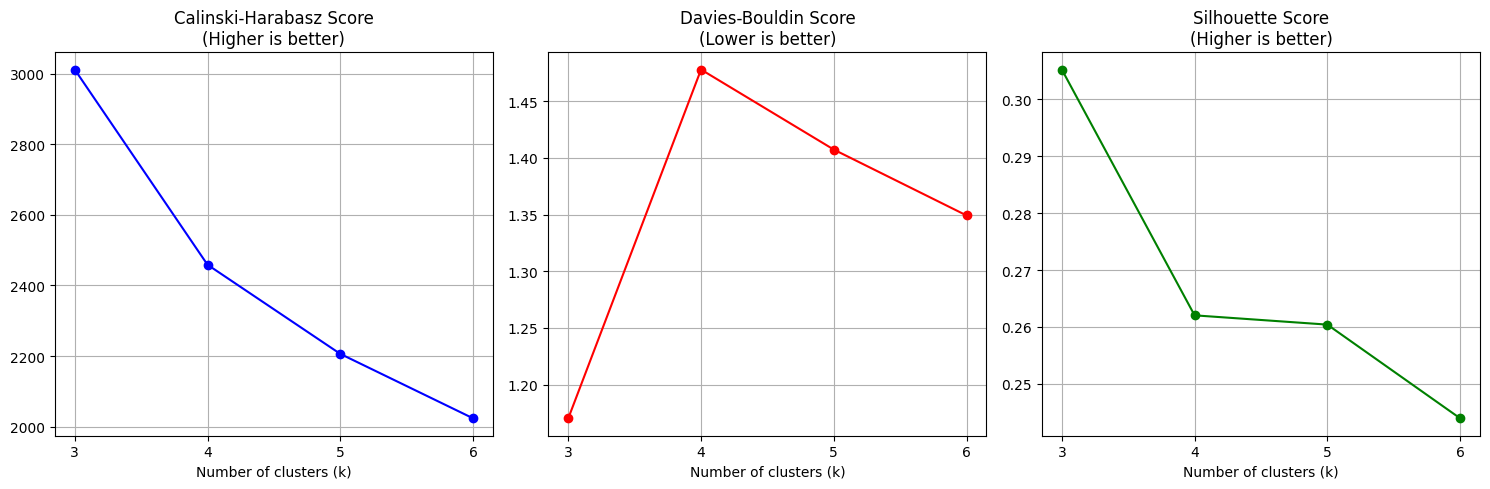

Optimal k according to Calinski-Harabasz (Max): 3
Optimal k according to Davies-Bouldin (Min): 3
Optimal k according to Silhouette (Max): 3


In [7]:
# Define the range of k values you want to test
k_values = range(3, 7)

# Initialize lists to store the metrics
ch_scores = []
db_scores = []
sil_scores = []
cluster_results = {}

# Calculate metrics for each k
for k in k_values:
    # Run K-means on the FAMD data
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_famd)
    cluster_results[k] = labels
    
    # Calculate and store the three scores (Defaulting to Euclidean distance on X_famd)
    ch_scores.append(calinski_harabasz_score(X_famd, labels))
    db_scores.append(davies_bouldin_score(X_famd, labels))
    sil_scores.append(silhouette_score(X_famd, labels))

# Plot evaluation metrics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calinski-Harabasz (Higher is better)
ax1.plot(k_values, ch_scores, 'bo-')
ax1.set_title('Calinski-Harabasz Score\n(Higher is better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_xticks(k_values)
ax1.grid(True)

# Davies-Bouldin (Lower is better)
ax2.plot(k_values, db_scores, 'ro-')
ax2.set_title('Davies-Bouldin Score\n(Lower is better)')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_xticks(k_values)
ax2.grid(True)

# Silhouette (Higher is better)
ax3.plot(k_values, sil_scores, 'go-')
ax3.set_title('Silhouette Score\n(Higher is better)')
ax3.set_xlabel('Number of clusters (k)')
ax3.set_xticks(k_values)
ax3.grid(True)

plt.tight_layout()
plt.show()

# Print optimal values automatically
best_ch_k = k_values[np.argmax(ch_scores)]
best_db_k = k_values[np.argmin(db_scores)]
best_sil_k = k_values[np.argmax(sil_scores)]

print(f"Optimal k according to Calinski-Harabasz (Max): {best_ch_k}")
print(f"Optimal k according to Davies-Bouldin (Min): {best_db_k}")
print(f"Optimal k according to Silhouette (Max): {best_sil_k}")

# K-Means Clustering

**Thanks to FAMD, we can now use K-Means**, the standard clustering algorithm based on Euclidean distances.

To begin visualizing the results of the K-Means algorithm, the code produces:

* A **2D scatter plot of the two principal dimensions**, which are the dimensions that explain the majority of the variance. These correspond to Component 0 (Dim_1) and Component 1 (Dim_2) that we analyzed previously.

* A **3D scatter plot of the three principal dimensions**,

* A **table showing the values of the `active_cols`** ('Wealth', 'Income', 'Debt', 'Saving', 'Luxury', 'LifeStyle', 'Investments') for each cluster.

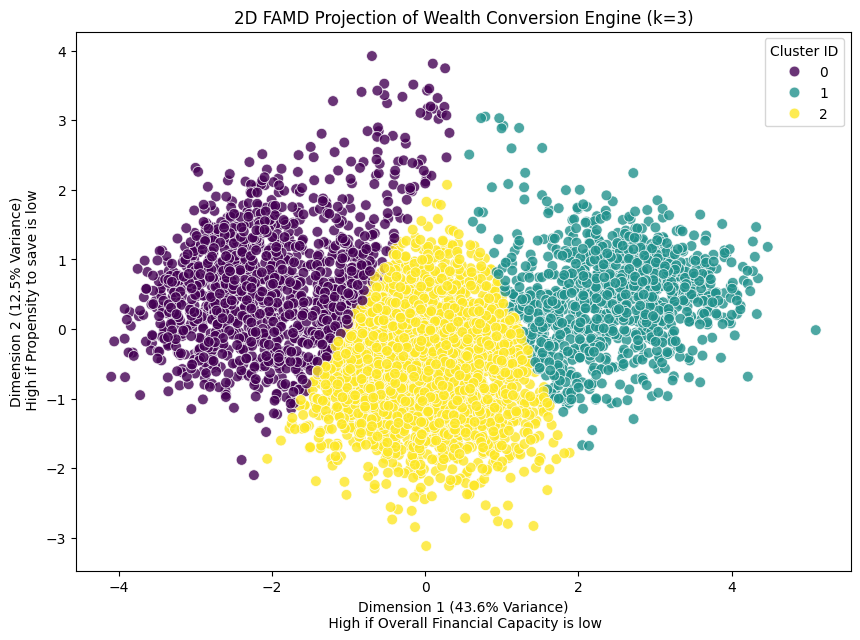

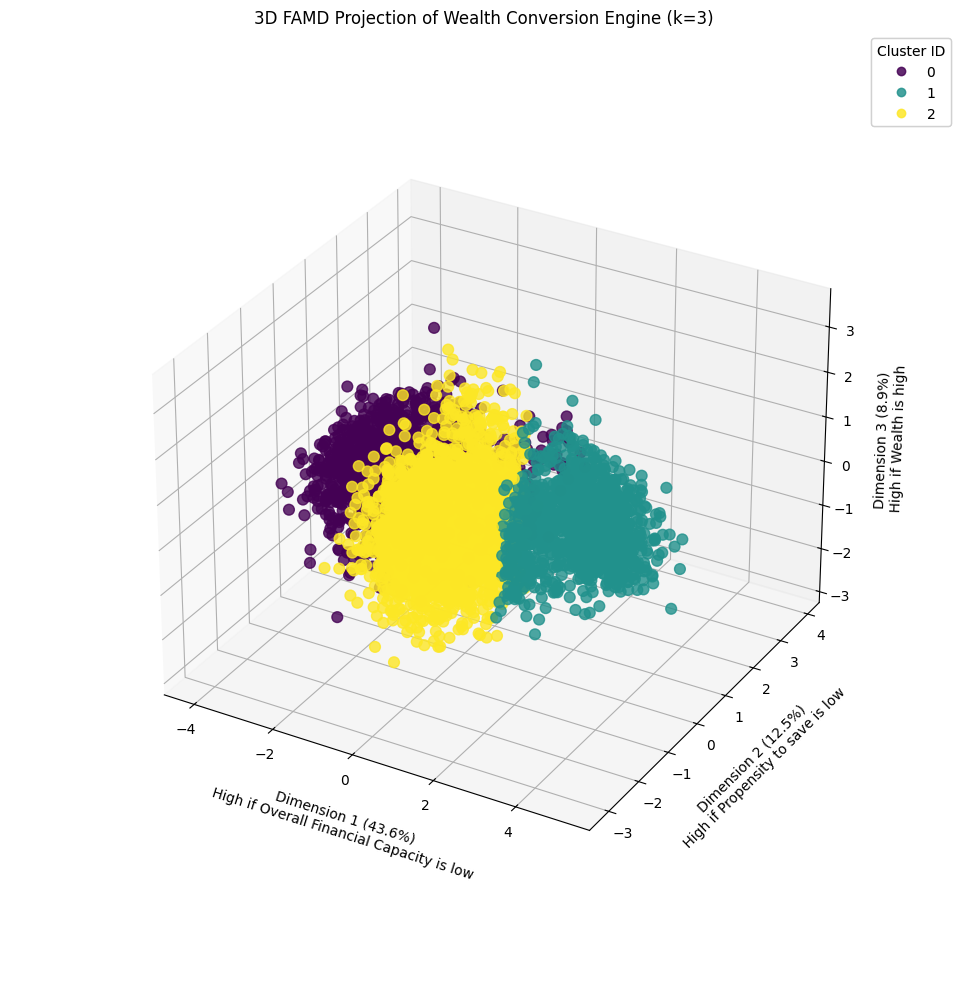


--- THE FINANCIAL PERSONAS (Averages by Cluster) ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
Cluster_ID,,,,,,,
0,0.77,0.78,0.55,0.57,0.75,0.70,3
1,0.37,0.37,0.16,0.30,0.24,0.27,2
2,0.57,0.56,0.48,0.59,0.43,0.42,3


In [8]:
#Execution of k-means
optimal_k = 3
kmeans = KMeans(optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_famd)

# Plot the Manifold (SCATTER PLOT 2D)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_famd['Dim_1'], 
    y=X_famd['Dim_2'], 
    hue=cluster_labels, 
    palette='viridis', 
    s=60,
    alpha=0.8
)

plt.title(f'2D FAMD Projection of Wealth Conversion Engine (k={optimal_k})')
plt.xlabel(f'Dimension 1 ({explained_variance[0]:.1f}% Variance)\n High if Overall Financial Capacity is low')
plt.ylabel(f'Dimension 2 ({explained_variance[1]:.1f}% Variance)\n High if Propensity to save is low')
plt.legend(title='Cluster ID')
plt.show()


# PLOT 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_famd['Dim_1'], 
    X_famd['Dim_2'], 
    X_famd['Dim_3'], 
    c=cluster_labels,
    cmap='viridis',
    s=60, 
    alpha=0.8
)

ax.set_title(f'3D FAMD Projection of Wealth Conversion Engine (k={optimal_k})')
ax.set_xlabel(f'Dimension 1 ({explained_variance[0]:.1f}%)\n High if Overall Financial Capacity is low', labelpad=20)
ax.set_ylabel(f'Dimension 2 ({explained_variance[1]:.1f}%)\n High if Propensity to save is low', labelpad=20)
ax.set_zlabel(f'Dimension 3 ({explained_variance[2]:.1f}%)\n High if Wealth is high', labelpad=15)

legend = ax.legend(*scatter.legend_elements(), title="Cluster ID")
ax.add_artist(legend)

ax.set_box_aspect(None, zoom=0.8)

plt.tight_layout() 
plt.show()


# Profile the Clusters to find the Business Target
df_active_mixed['Cluster_ID'] = cluster_labels

print("\n--- THE FINANCIAL PERSONAS (Averages by Cluster) ---")
profile_active = df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'Luxury': 'mean',
    'LifeStyle': 'mean',
    'Investments': lambda x: x.mode()[0] # The most frequent investment level
}).round(2)

display(profile_active)

# Interpreting the Results

After applying K-Means clustering with our optimal $k=3$, we perform a thorough statistical examination of the clusters. To gain clear visual insights and a comprehensive overview of each cluster's characteristics, we will generate multiple complementary plots:

* **Heatmap**: Visualizing the average values of 'Wealth', 'Income', 'Debt', 'Saving', 'Luxury', and 'LifeStyle'.

* **Bar Chart (Investments)**: Showing the distribution of investment levels within each segment.

* **Grouped Bar Chart**: Comparing the financial metrics of 'Wealth', 'Income', 'Debt', and 'Saving' side-by-side for each cluster.

* **Radar Chart**: Offering a multidimensional view of the cluster profiles.



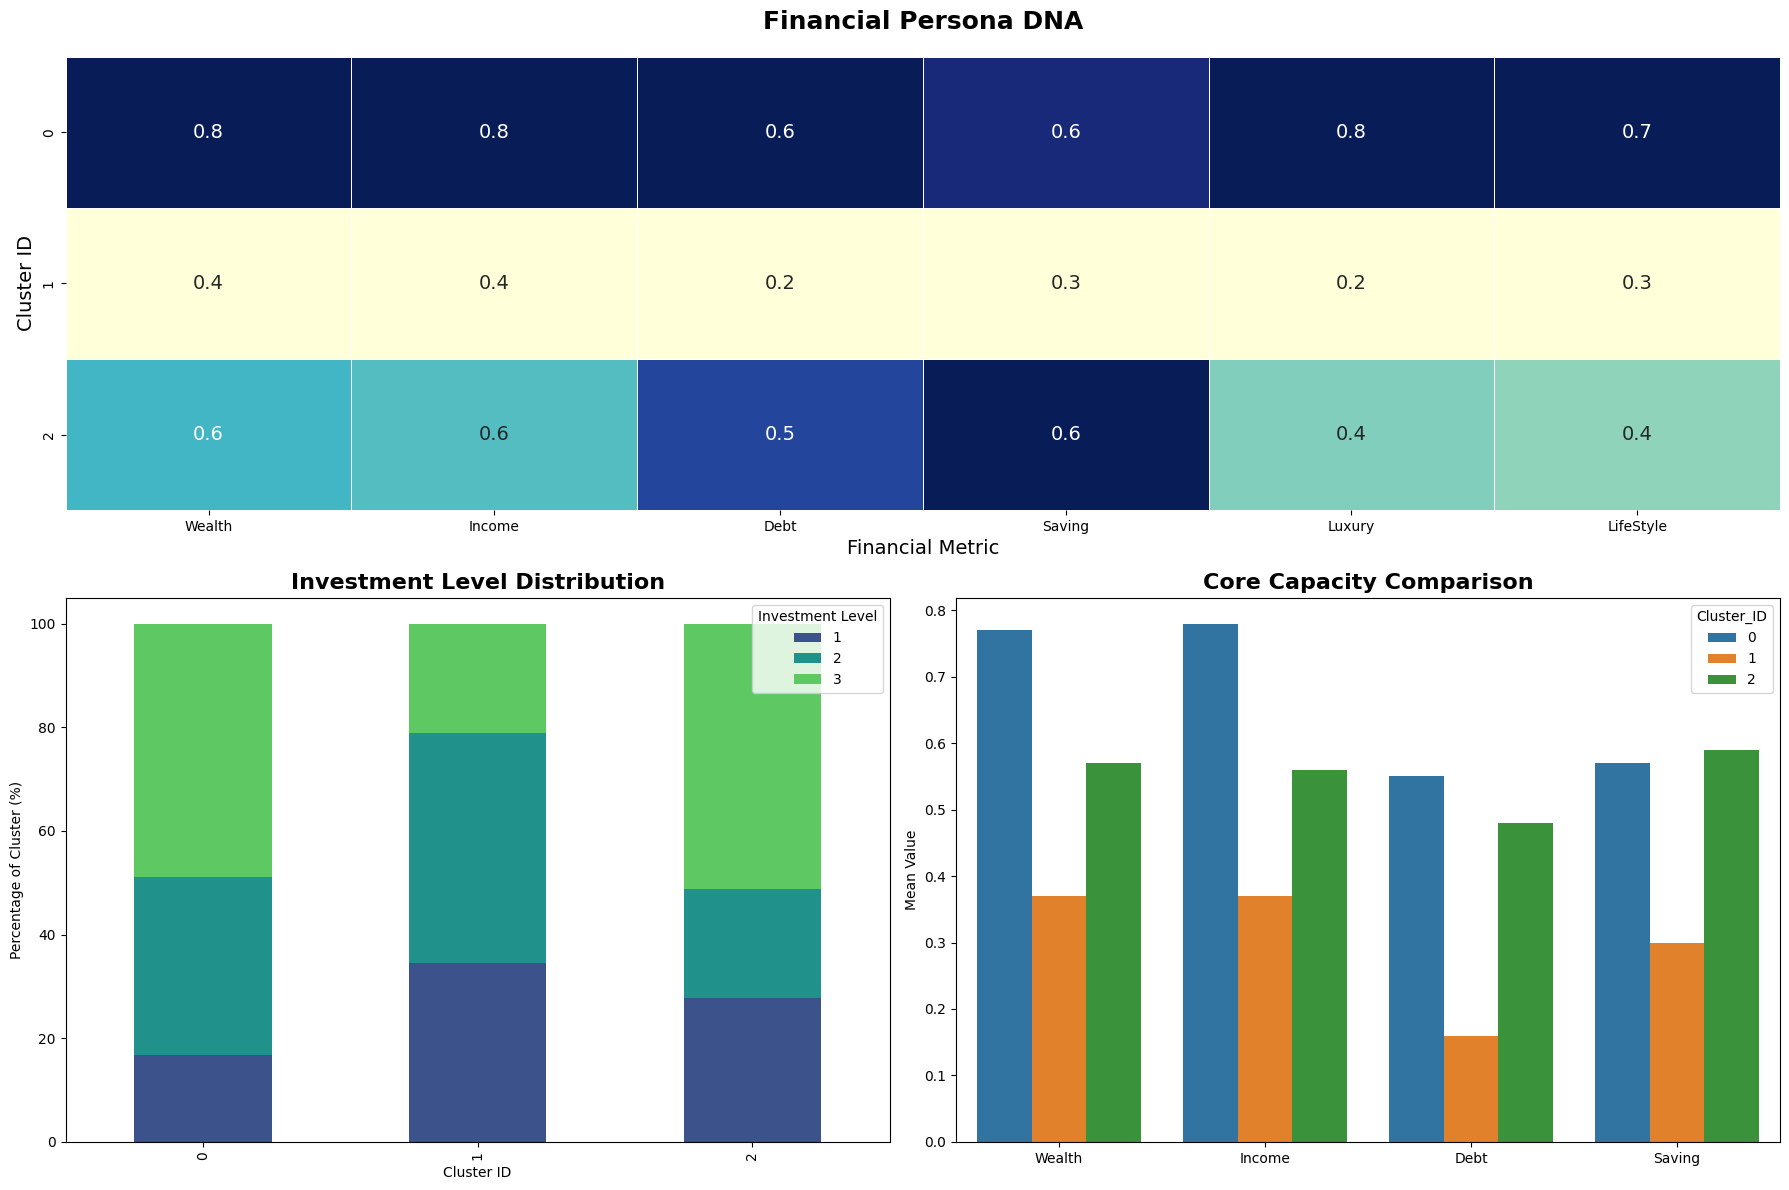

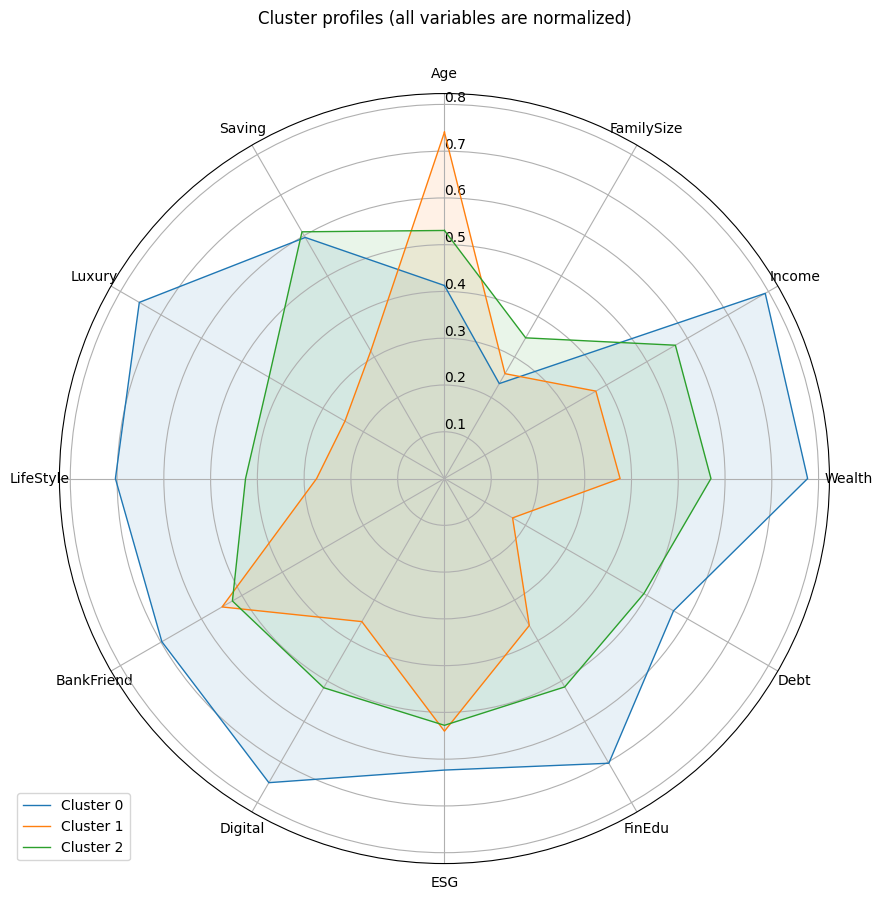

In [9]:
# We exclude 'Investments' for the heatmap because it's categorical
num_profile = profile_active.drop(columns=['Investments'])

# Scale the means (0 to 1) just for the heatmap colors to ensure 
# high values are dark and low values are light across different scales.
scaler = MinMaxScaler()
scaled_profile = pd.DataFrame(
    scaler.fit_transform(num_profile), 
    columns=num_profile.columns, 
    index=num_profile.index
)


fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# THE HEATMAP
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(scaled_profile, annot=num_profile, fmt=".1f", cmap="YlGnBu", 
            cbar=False, linewidths=.5, ax=ax0, annot_kws={"size": 14})
ax0.set_title("Financial Persona DNA", fontsize=18, fontweight='bold', pad=20)
ax0.set_xlabel("Financial Metric", fontsize=14)
ax0.set_ylabel("Cluster ID", fontsize=14)

# INVESTMENT LEVEL DISTRIBUTION
ax1 = fig.add_subplot(gs[1, 0])
# We look at the actual distribution of Investments for each cluster
inv_dist = pd.crosstab(df_active_mixed['Cluster_ID'], df_active_mixed['Investments'], normalize='index') * 100
inv_dist.plot(kind='bar', stacked=True, ax=ax1, color=sns.color_palette("viridis", 3))
ax1.set_title("Investment Level Distribution", fontsize=16, fontweight='bold')
ax1.set_ylabel("Percentage of Cluster (%)")
ax1.set_xlabel("Cluster ID")
ax1.legend(title="Investment Level", loc='upper right')

# Comparison of Wealth, Income, Debt and Saving
ax2 = fig.add_subplot(gs[1, 1])
# Melting for a grouped bar chart
melted_active = num_profile[['Wealth', 'Income', 'Debt', 'Saving']].reset_index().melt(id_vars='Cluster_ID')
sns.barplot(data=melted_active, x='variable', y='value', hue='Cluster_ID', ax=ax2, palette='tab10')
ax2.set_title("Core Capacity Comparison", fontsize=16, fontweight='bold')
ax2.set_ylabel("Mean Value")
ax2.set_xlabel("")

plt.tight_layout()
plt.show()


# RADAR Chart
radar_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = cluster_labels

def plot_cluster_radar(data):
    # Create a copy of the data for normalization
    plot_data = data.copy()
    
    # Normalize all numerical variables using MinMaxScaler
    scaler = MinMaxScaler()
    plot_data[radar_cols] = scaler.fit_transform(plot_data[radar_cols])
    
    # Calculate mean values for each numerical variable by cluster
    cluster_means = plot_data.groupby('Cluster')[radar_cols].mean()
    
    # Set up the radar chart
    categories = radar_cols
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot for each cluster
    for cluster in range(3):
        values = cluster_means.loc[cluster].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster}')
        ax.fill(angles, values, alpha=0.1)
    
    # Set chart properties
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    plt.xticks(angles[:-1], categories)
    ax.set_title("Cluster profiles (all variables are normalized)", y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.show()

# Execute visualizations
plot_cluster_radar(data_with_clusters)


# Cluster 0 

In [10]:
# Remove active feature
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster -> 0 in this case
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}\n\n")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# Numerical Distributions (Age, Digital, BankFriend, FinEdu)
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"\n--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 50.4
Most common Gender: 0
Most common familySize : 1
Digital Propensity: 0.73
BankFriend Propensity: 0.72
Financial Education: 0.68
Most common Job: 2
Most common Area: 1
Most common CitySize: 3


--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    52.7%
1    47.3%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    76.4%
1    12.2%
3     5.2%
5     3.9%
4     2.3%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    80.4%
2    13.1%
3     6.5%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    56.1%
2    31.8%
1    12.1%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    40.9%
2    24.6%
3    16.4%
4    14.2%
5     2.5%
6     1.5%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  50.369842  0.729671    0.721374  0.676584
min   19.

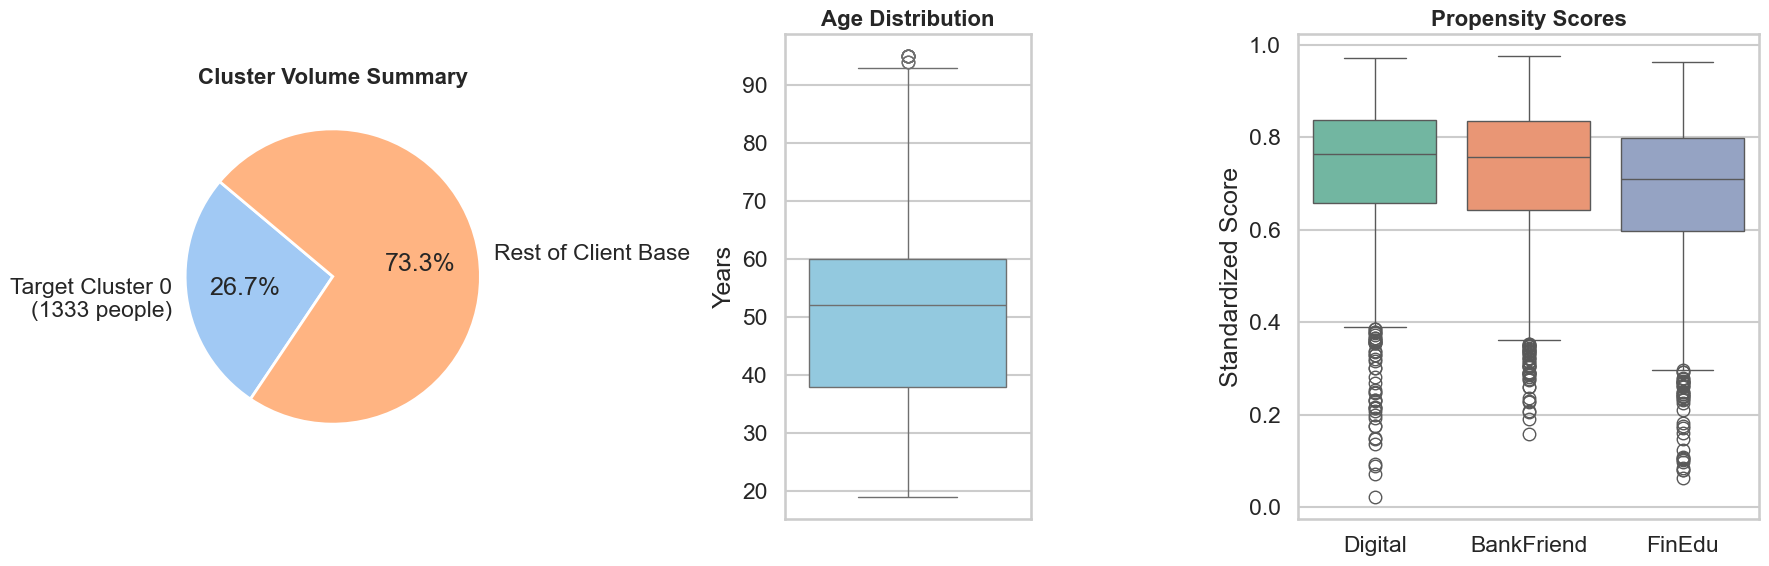

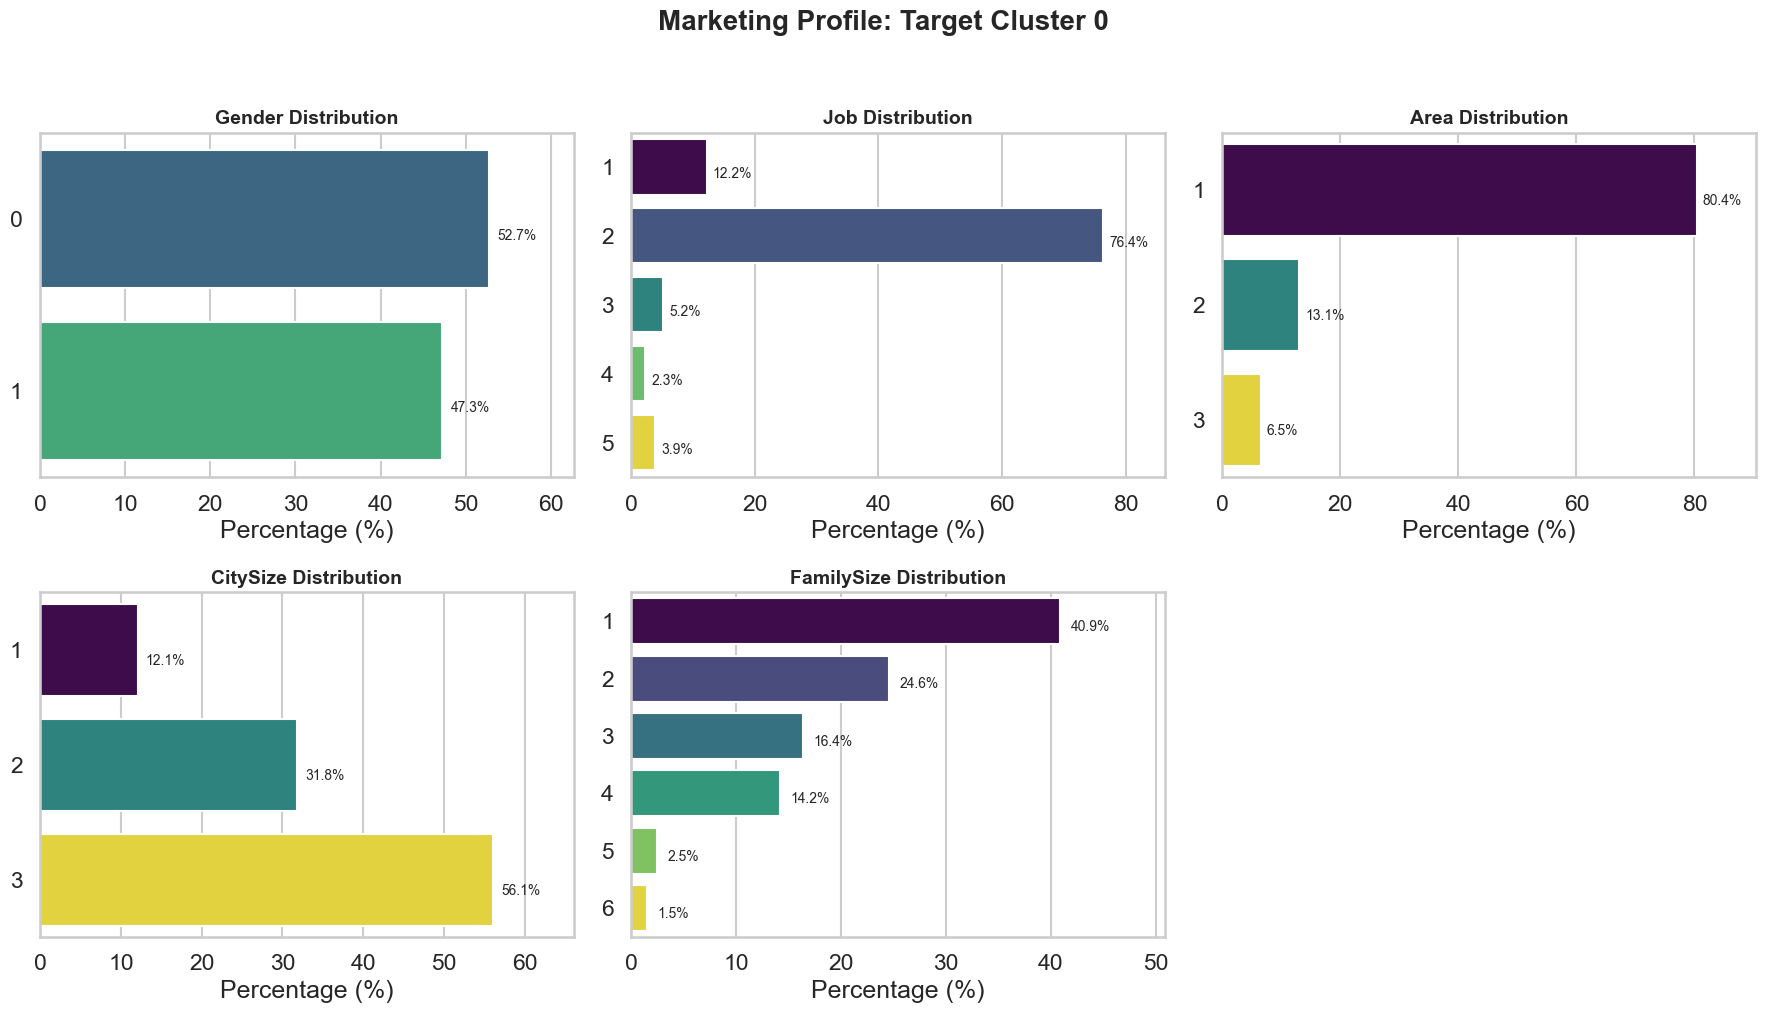

In [11]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend', 'FinEdu']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()



# CATEGORICAL DISTRIBUTIONS
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cluster 1

In [ ]:
# Remove active feature
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster -> 1 in this case
target_cluster_id = 1
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}\n\n")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# Numerical Distributions (Age, Digital, BankFriend, FinEdu)
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 1 ---
Average Age: 75.3
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.34
BankFriend Propensity: 0.60
Financial Education: 0.35
Most common Job: 5
Most common Area: 1
Most common CitySize: 2


--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 1 ---

--- Gender Distribution ---
Gender
1    54.9%
0    45.1%
Name: proportion, dtype: object

--- Job Distribution ---
Job
5    58.8%
2    19.8%
1    18.2%
4     2.4%
3     0.7%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    66.5%
2    23.4%
3    10.1%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    47.6%
1    43.2%
3     9.2%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    33.5%
2    27.5%
3    20.1%
4    15.0%
5     2.5%
6     1.4%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  75.281335  0.343238    0.597049  0.349228
min   19.

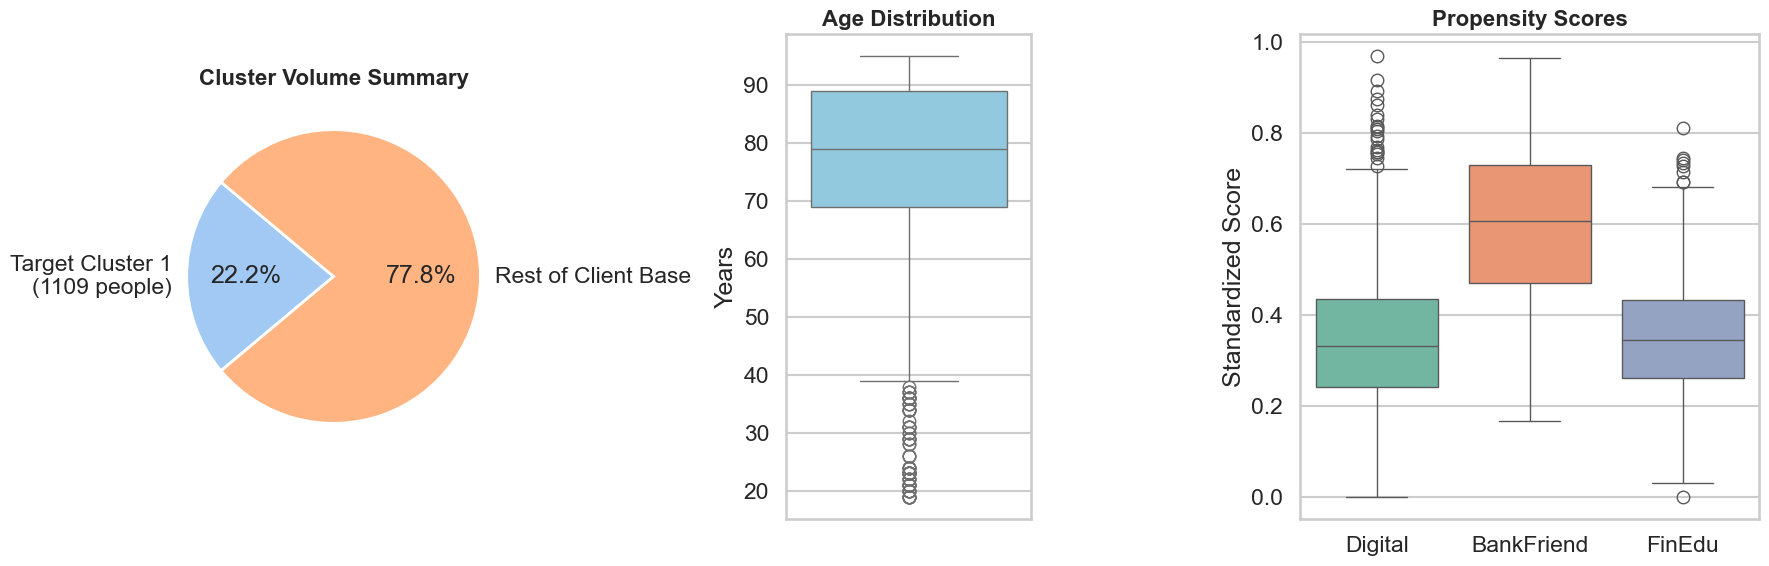

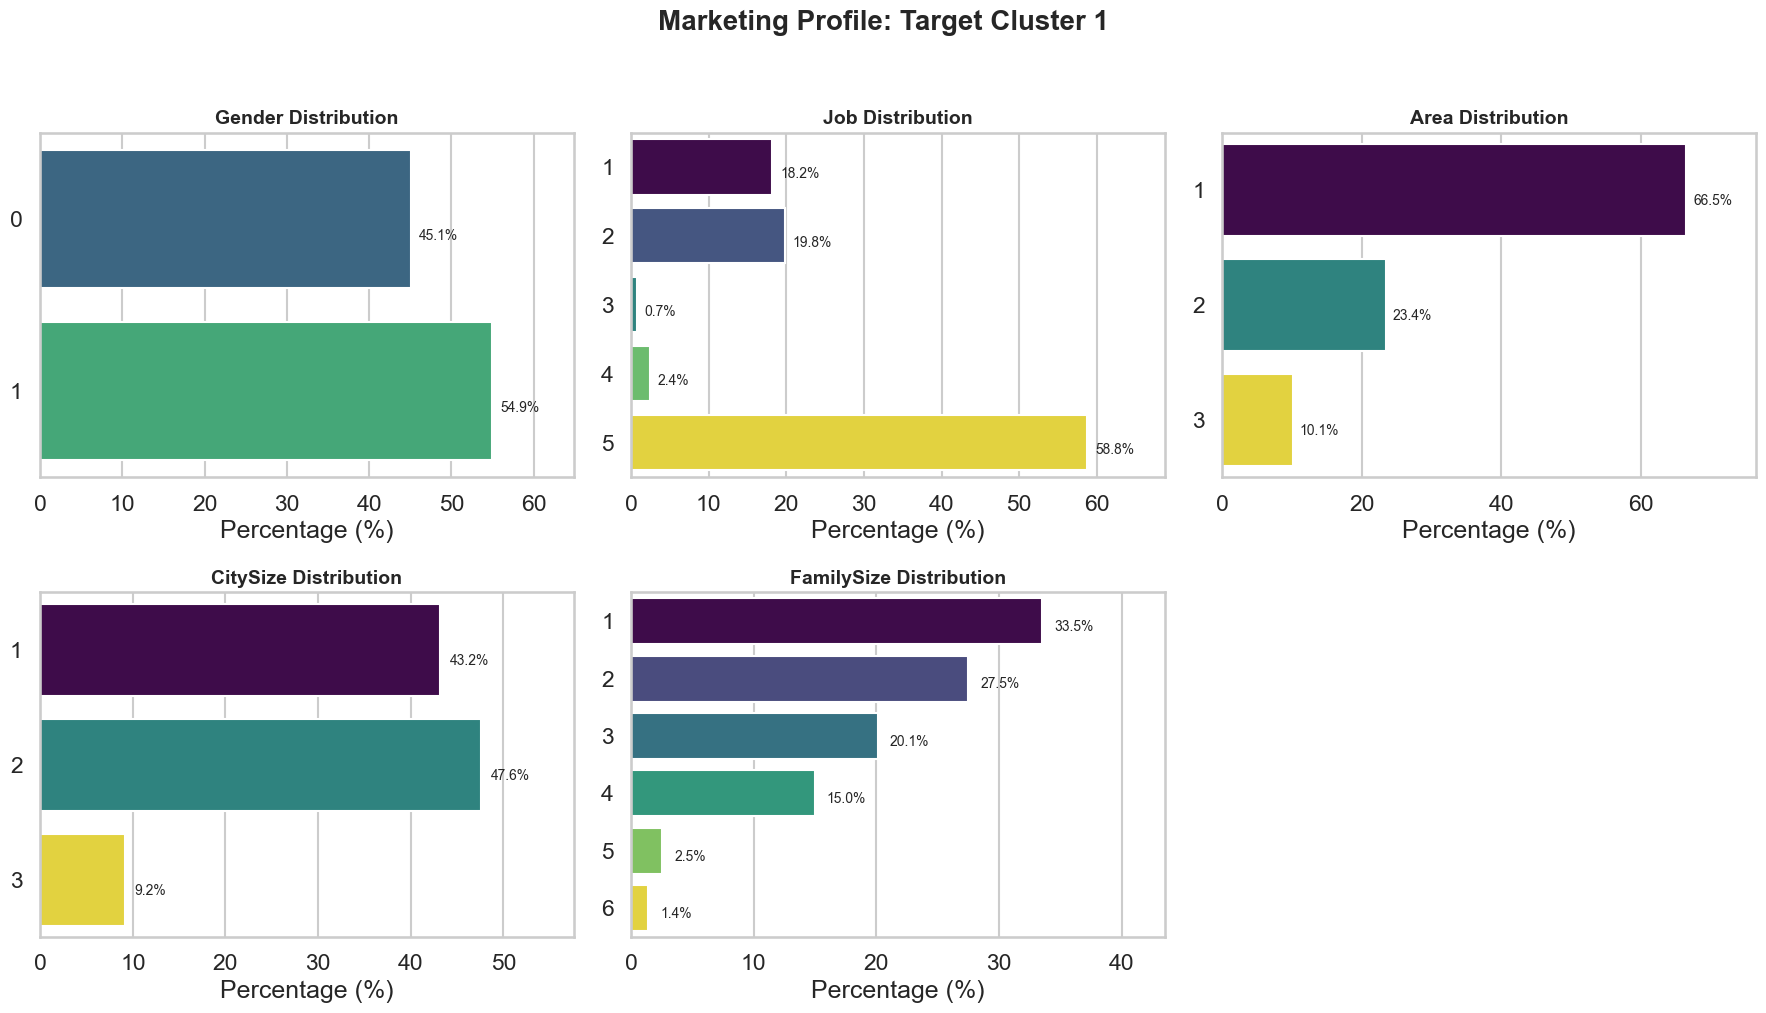

In [13]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend', 'FinEdu']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()



# CATEGORICAL DISTRIBUTIONS
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cluster 2

In [ ]:
# Remove active feature
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster -> 2 in this case
target_cluster_id = 2
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}\n\n")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# Numerical Distributions (Age, Digital, BankFriend, FinEdu)
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 2 ---
Average Age: 59.3
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.50
BankFriend Propensity: 0.58
Financial Education: 0.50
Most common Job: 2
Most common Area: 1
Most common CitySize: 2


--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 2 ---

--- Gender Distribution ---
Gender
1    54.8%
0    45.2%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    80.0%
1     9.5%
5     6.0%
3     2.6%
4     1.9%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    71.0%
2    15.2%
3    13.8%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    43.4%
1    39.6%
3    17.0%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    27.0%
2    22.2%
3    21.8%
4    14.4%
5     8.2%
6     6.4%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  59.315955  0.501872    0.575683  0.495183
min   19.

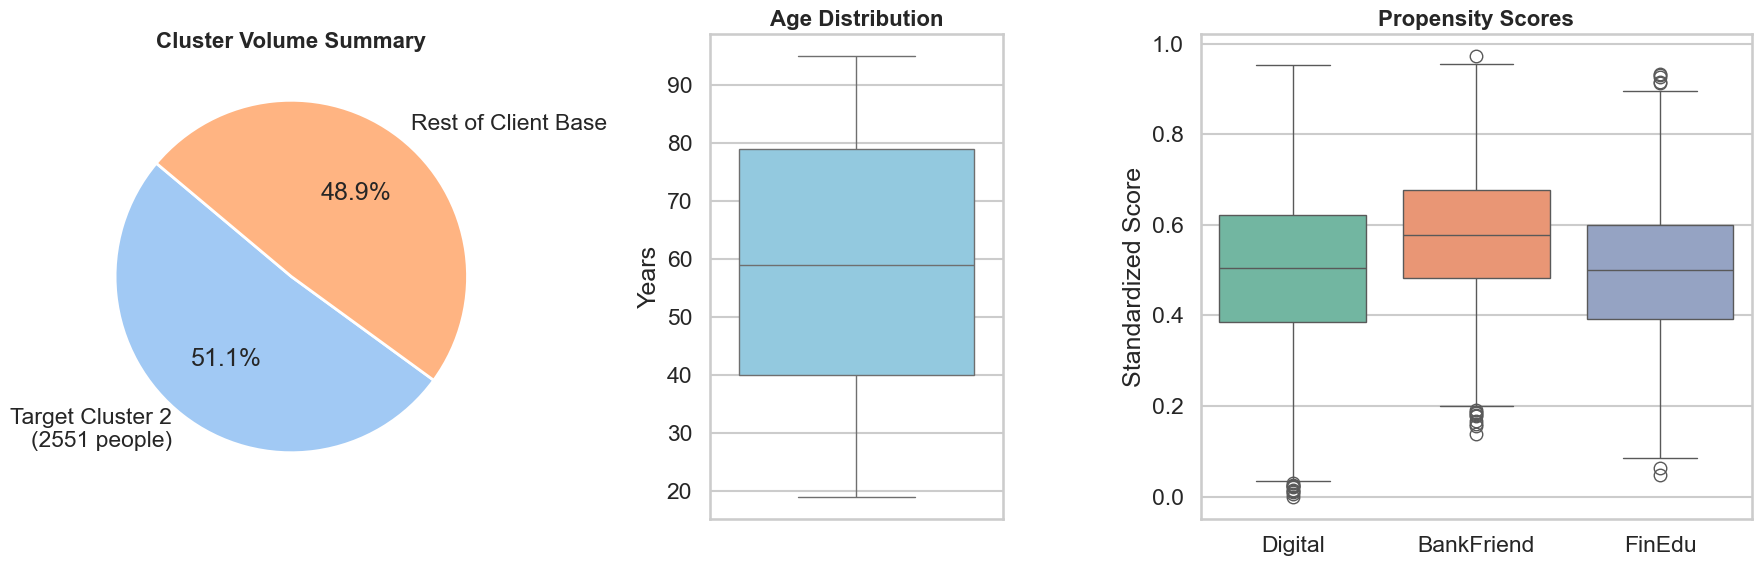

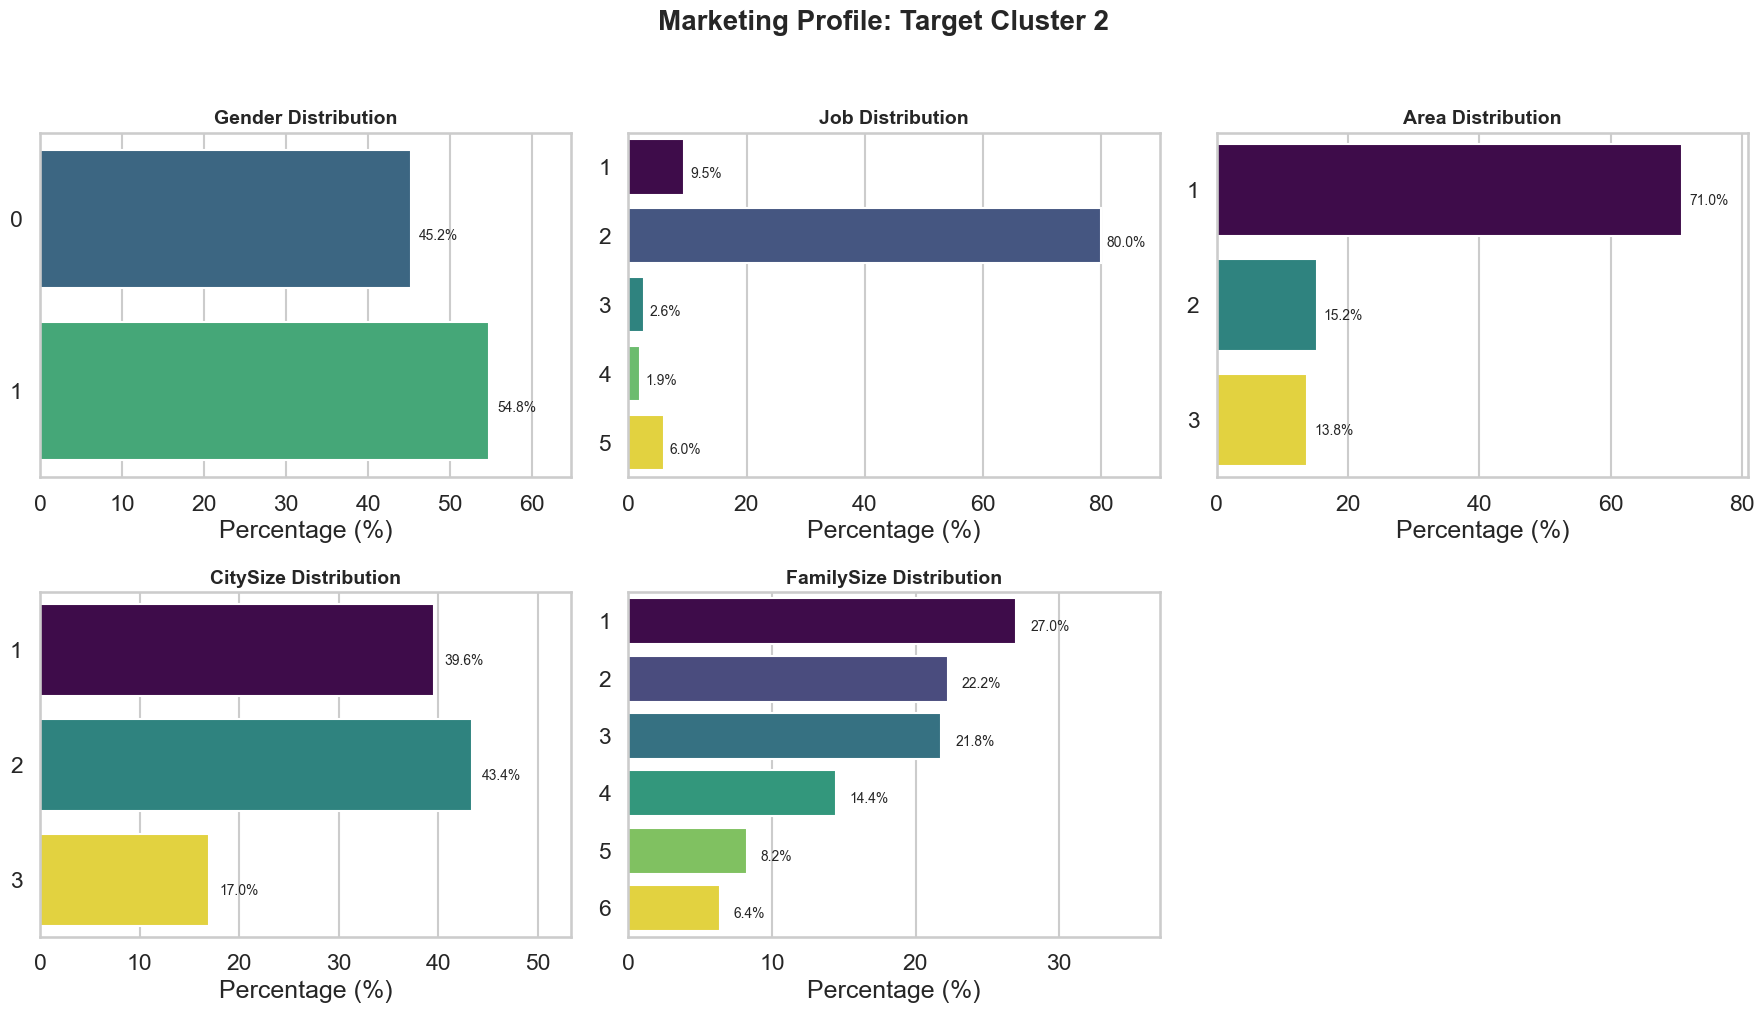

In [15]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend', 'FinEdu']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()



# CATEGORICAL DISTRIBUTIONS
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Customer Profile Analysis - Personas

Through cluster analysis, we have identified each cluster with a specific persona as follows:

# Cluster 0: The "Young Urban Professional"
* **Demographics:** Medium-low age. They predominantly live in large metropolitan areas.
* **Financial Situation:** They hold the highest levels of **Income** and **Wealth** across all groups, paired with excellent **Saving** capabilities. Their high **Debt** suggests a structured use of credit.
* **Lifestyle:** They don't hold back on spending, showing the highest scores in both **Luxury** and **LifeStyle**.
* **Behavior:** Highly digitalized (peak **Digital**) with top-tier financial literacy (**FinEdu**). Despite being tech-savvy, they maintain a very strong relationship with their bank (**BankFriend**), likely relying on advanced wealth management or premium advisory services.

# Cluster 1: The "Conservative Retiree"
* **Demographics:** The oldest group (maximum peak in **Age**) with a small household size (**FamilySize**).
* **Financial Situation:** Below-average **Income** and **Wealth** (likely relying on fixed pensions), and practically non-existent **Debt**.
* **Lifestyle:** A very cautious and frugal life, with minimal spending on **Luxury** and **LifeStyle**. They do, however, show a baseline sensitivity to **ESG** factors.
* **Behavior:** They are not tech-savvy (lowest **Digital**) and possess low modern financial literacy (**FinEdu**). Their banking relationship (**BankFriend**) remains moderate and strictly traditional.

# Cluster 2: The "Average Family"
* **Demographics:** Middle-aged with the largest household size (highest **FamilySize**), representing a typical family setup.
* **Financial Situation:** Decent **Income** and solid **Saving** habits, combined with the lowest level of **Debt** among the three clusters.
* **Lifestyle:** They maintain a restrained everyday lifestyle (low **LifeStyle**) but occasionally afford valuable purchases or durable goods (relatively high **Luxury**). 
* **Behavior:** They don't stand out for digitalization or financial literacy (average/low **Digital** and **FinEdu**), representing a stable, traditional client base with a good awareness of sustainability (**ESG**).